In [1]:
import sys
import os
import jax
import jax.numpy as np
import jax.tree as jtu
import jax.scipy as jsp
import jax.random as jr
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Basic jax import
jax.config.update("jax_enable_x64", True)

# Check if running on remote, and set directory to where notebook is run
if jax.devices()[0].platform == "gpu":
    os.chdir("code/amigo_project/notebooks/calibration")
else:
    os.chdir("/Users/louis/PhD/Software/sandbox/amigo_project/notebooks/calibration")

# Add parent directories
paths = [os.path.abspath(os.path.join(os.getcwd(), path)) for path in ['..', "../.."]]
for path in paths:
    if path not in sys.path:
        sys.path.insert(0, path)
        
# Plotting set up
%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 120

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]
inferno_r = mpl.colormaps["inferno_r"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)
inferno_r.set_bad("k", 0.5)

def merge_cbar(ax):
    return make_axes_locatable(ax).append_axes("right", size="5%", pad=0.0)

ERROR:2025-05-28 15:15:05,361:jax._src.xla_bridge:647: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/louis/miniconda3/envs/jax_gpu/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 645, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/louis/miniconda3/envs/jax_gpu/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 105, in initialize
    triton.register_compilation_handler(
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: module 'jax._src.lib.triton' has no attribute 'register_compilation_handler'


# Load the known binaries depending on the data set

In [2]:
# # HD206893 b & c 26th Oct 2022, from whereistheplanet.com
# binaries = [
#     (-43.806, 190.184),  # Ra, Dec
#     (-1.357, -90.231),  # Ra, Dec
# ]

# companions = {
#     "b": binaries[0],
#     "c": binaries[1],
# }
# fluxes = {
#     "b": (-4, -2),  # HD206893 b
#     "c": (-5, -2),  # HD206893 c
# }

In [3]:
# import dLux.utils as dlu

# # Values from here, Fig 16:
# # https://www.stsci.edu/files/live/sites/www/files/home/jwst/documentation/_documents/jwst-science-performance-report.pdf
# pa, sep = -79.4, 325.6
# ra = sep * np.sin(dlu.deg2rad(pa))
# dec = sep * np.cos(dlu.deg2rad(pa))
# binaries = [
#     (ra, dec),
# ]

# companions = {
#     "b": binaries[0],
# }
# fluxes = {
#     "b": (-3, 0), 
# }

In [4]:
import dLux.utils as dlu

binaries = [
    (
        150 * np.sin(dlu.deg2rad(131)),
        150 * np.cos(dlu.deg2rad(131)),
    ),
    (
        218 * np.sin(dlu.deg2rad(270)),
        218 * np.cos(dlu.deg2rad(270)),
    ),
]

companions = {
    "b": binaries[0],
    "c": binaries[1],
}
fluxes = {
    "b": (-6, 0),
    "c": (-6, 0),
}

# Load the visibilities and analyse it

In [5]:
import dLux.utils as dlu
from amigo.misc import tqdm
from amigo.vis_analysis import AmigoOIData, analyse_vis

# Circle making function
make_circle = lambda position, diameter, **kwargs: mpl.patches.Circle(
    position, diameter / 2, color="w", fill=False, linewidth=2, **kwargs
)


path = "../../GPU_files/results"
cal_vis_outputs = np.load(f"{path}/GTO1242/cal_vis.npy", allow_pickle=True).item()
# cal_vis_outputs = np.load(f"{path}/GO1843/cal_vis.npy", allow_pickle=True).item()
# cal_vis_outputs = np.load(f"{path}/COMM1903/cal_vis.npy", allow_pickle=True).item()


# Calculate the log-likelihoods
outputs = {}
for filt, oi_data in tqdm(cal_vis_outputs.items()):
    outputs[filt] = analyse_vis(
        AmigoOIData(oi_data),
        size=650,  # mas
        n_pts=500,  # number of points in the final grid
        n_grid=60,  # number of initial grid points
        n_batch=1,  # number of batches to calculate the likelihood
        min_flux=-6,  # minimum log flux range
        tol=1e-8,  # tolerance for the optimizer (linear OR log space)
        max_steps=512,  # maximum number of steps for the optimizer
        n_sigma=3.0,  # number of sigma for the upper limits
        log=False,
    )

  0%|          | 0/3 [00:00<?, ?it/s]

[Text(0.5, 1.0, 'Broadband Log-Likelihood'),
 Text(0.5, 0, '$\\Delta$RA [mas]'),
 Text(0, 0.5, '$\\Delta$DEC [mas]')]

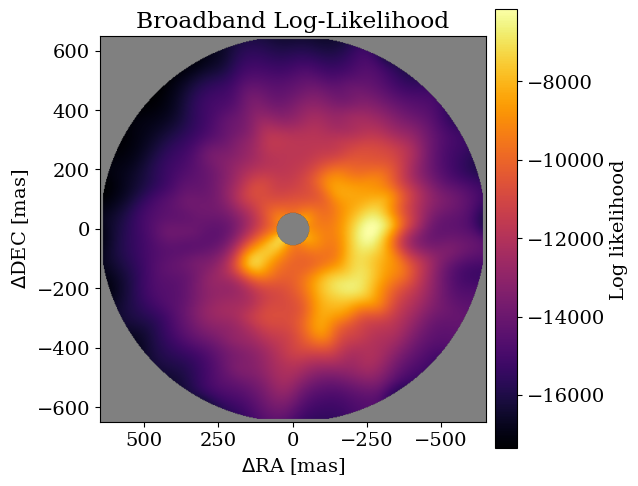

In [6]:
bb_loglike = np.array([vals["loglike_im"] for vals in outputs.values()]).sum(0)
extent = outputs["F480M"]["extent"]

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
im = ax.imshow(bb_loglike, cmap=inferno, aspect="equal", extent=extent)
fig.colorbar(im, ax=ax, shrink=0.95, label="Log likelihood", pad=0.02)
ax.set(
    title="Broadband Log-Likelihood",
    xlabel="$\\Delta$RA [mas]",
    ylabel="$\\Delta$DEC [mas]",
)

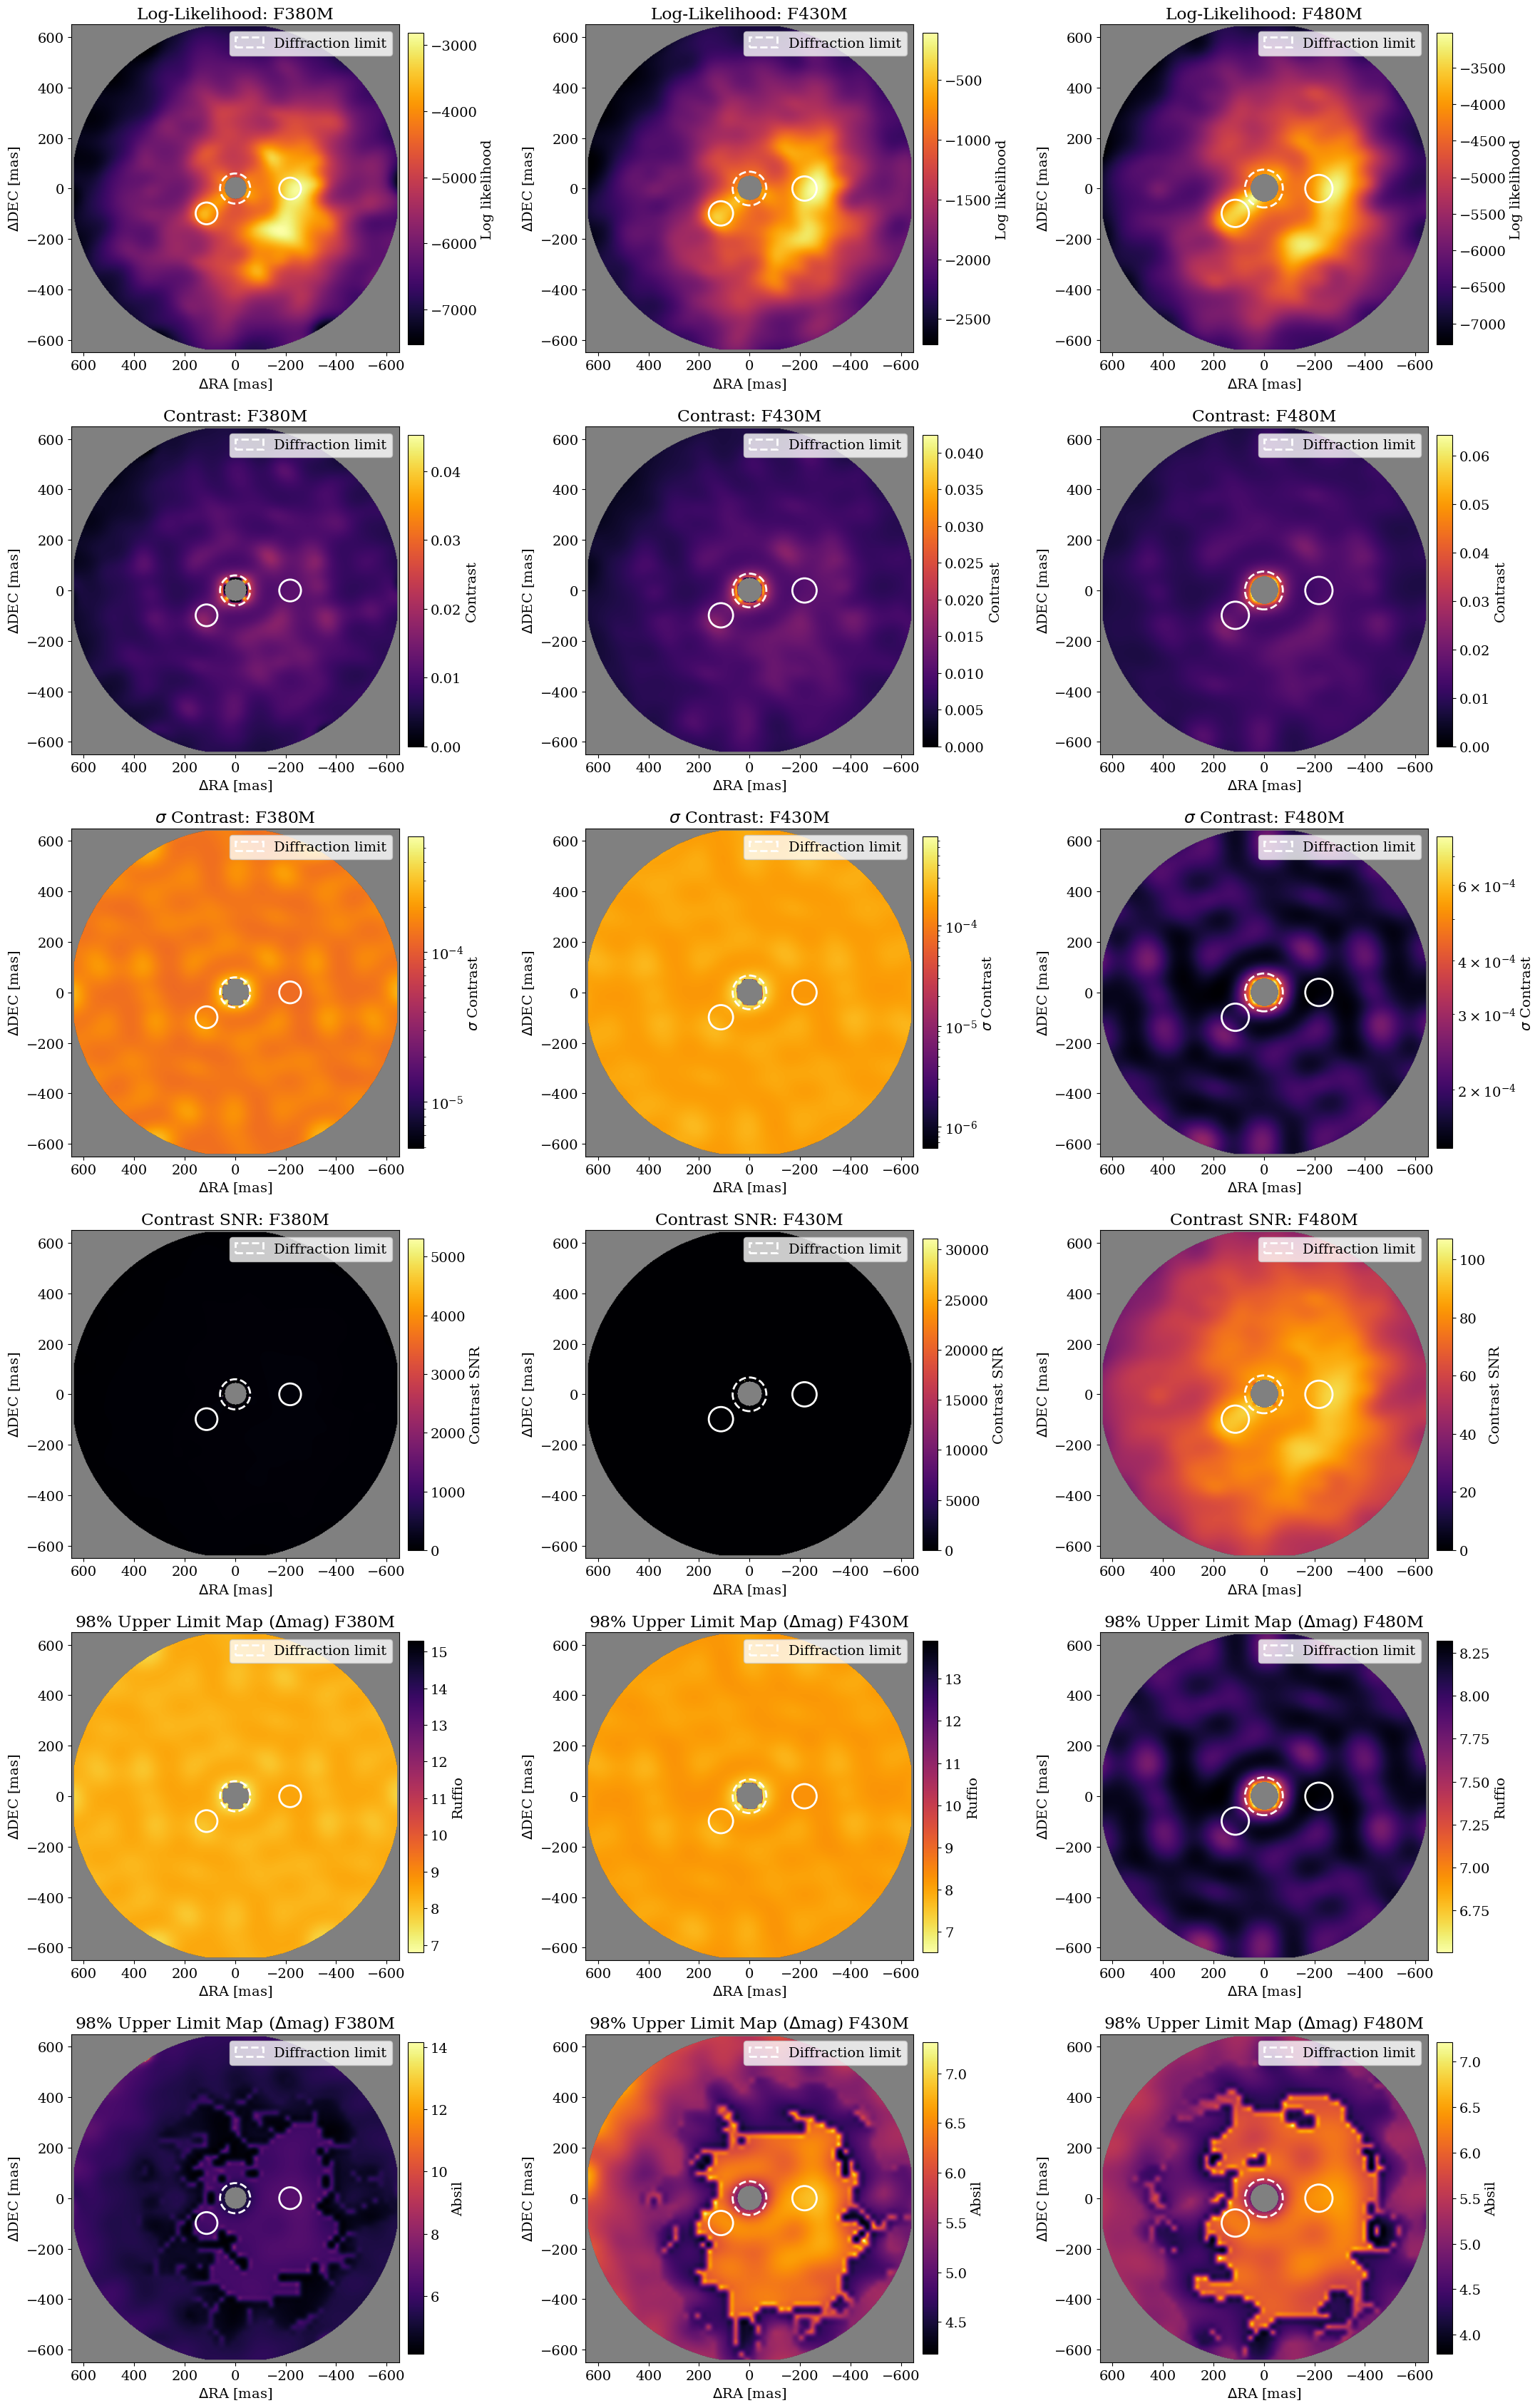

In [7]:
from amigo.optical_models import AMIOptics

optics = AMIOptics()

plt.figure(figsize=(22, 34))
for i, (filt, output) in enumerate(outputs.items()):
    loglike_im = output["loglike_im"]
    contrast_im = output["contrast_im"]
    sigma_im = output["sigma_im"]
    ruffio_im = output["ruffio_im"]
    limits_im = output["limits_im"]
    min_fov, max_fov = output["fov"]
    extent = output["extent"]
    wavel = output["oi_obj"].wavel

    diff_lim = 1e3 * dlu.rad2arcsec(wavel / optics.diameter)

    def add_to_ax(ax):
        [ax.add_patch(make_circle(binary, 2 * min_fov)) for binary in binaries]
        ax.add_patch(make_circle((0, 0), diff_lim, ls="--", label="Diffraction limit"))
        ax.legend()

    #
    ax = plt.subplot(6, 3, i + 1)
    plt.imshow(loglike_im, cmap=inferno, aspect="equal", extent=extent)
    plt.colorbar(shrink=0.95, label="Log likelihood", pad=0.02)
    ax.set(
        title=f"Log-Likelihood: {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax)

    norm = mpl.colors.PowerNorm(1, vmin=0)
    ax = plt.subplot(6, 3, i + 4)
    plt.imshow(contrast_im, cmap=inferno, aspect="equal", extent=extent, norm=norm)
    plt.colorbar(shrink=0.95, label="Contrast", pad=0.02)
    ax.set(
        title=f"Contrast: {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax)

    norm = mpl.colors.LogNorm()
    ax = plt.subplot(6, 3, i + 7)
    plt.imshow(sigma_im, cmap=inferno, aspect="equal", extent=extent, norm=norm)
    plt.colorbar(shrink=0.95, label=r"$\sigma$ Contrast", pad=0.02)
    ax.set(
        title=rf"$\sigma$ Contrast: {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax)

    norm = mpl.colors.PowerNorm(1, vmin=0)
    ax = plt.subplot(6, 3, i + 10)
    plt.imshow(
        contrast_im / sigma_im, cmap=inferno, aspect="equal", extent=extent, norm=norm
    )
    plt.colorbar(shrink=0.95, label="Contrast SNR", pad=0.02)
    ax.set(
        title=f"Contrast SNR: {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax)

    ax = plt.subplot(6, 3, i + 13)
    plt.imshow(
        -2.5 * np.log10(ruffio_im), cmap=inferno_r, aspect="equal", extent=extent
    )
    # plt.imshow(ruffio_im, cmap=inferno_r, aspect="equal", extent=extent)
    plt.colorbar(shrink=0.95, label="Ruffio", pad=0.02)
    ax.set(
        title=f"98% Upper Limit Map ($\\Delta$mag) {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax)

    ax = plt.subplot(6, 3, i + 16)
    plt.imshow(-2.5 * np.log10(limits_im), cmap=inferno, aspect="equal", extent=extent)
    plt.colorbar(shrink=0.95, label="Absil", pad=0.02)
    ax.set(
        title=f"98% Upper Limit Map ($\\Delta$mag) {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax)

plt.tight_layout()
plt.show()

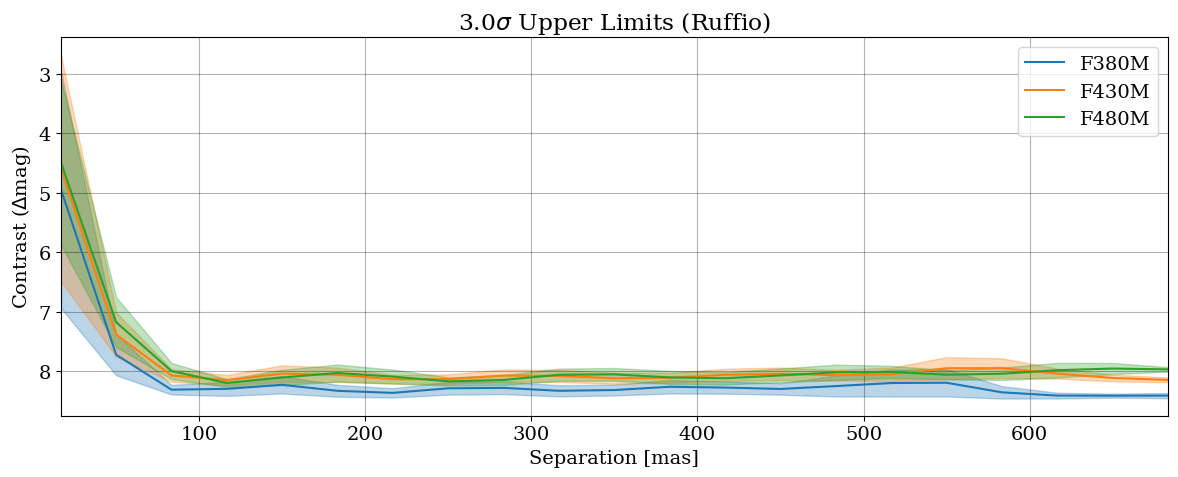

In [8]:
plt.figure(figsize=(12, 5))
for i, (filt, output) in enumerate(outputs.items()):
    rad_width, avg_width, std_width = output["ruffio"]
    n_sigma = output["n_sigma"]

    dx = 1000 / 60
    # plt.title("98% Upper Limits (Ruffio)")
    plt.title(rf"{n_sigma}$\sigma$ Upper Limits (Ruffio)")
    plt.plot(rad_width * dx, avg_width, label=f"{filt}")
    plt.fill_between(
        rad_width * dx,
        avg_width - std_width,
        avg_width + std_width,
        color=f"C{i}",
        alpha=0.3,
    )
    plt.ylabel("Contrast ($\\Delta$mag)")
    plt.xlabel("Separation [mas]")
    plt.gca().invert_yaxis()
    plt.xlim(
        np.nanmin(rad_width * dx + avg_width * 0.0),
        np.nanmax(rad_width * dx + avg_width * 0.0),
    )
    plt.grid(color="black", alpha=0.3)
    plt.legend(loc="best")
plt.tight_layout()
plt.show()

# Run a HMC on the known binaries

In [9]:
import numpyro as npy
import numpyro.distributions as dist


def sampling_fn(oi_objs, multi_model, r=75):

    dras, ddecs = [], []
    for comp, (ra, dec) in companions.items():

        # Define priors
        dra = npy.sample(f"Δ RA {comp}", dist.Uniform(ra - r, ra + r))
        ddec = npy.sample(f"Δ Dec {comp}", dist.Uniform(dec - r, dec + r))
        dras.append(dra)
        ddecs.append(ddec)

        # Track the outputs of the model and the PA/Sep/DMag
        _ = npy.deterministic(f"PA {comp}", dlu.rad2deg(np.arctan2(dec, dra)))
        _ = npy.deterministic(f"Sep {comp}", np.hypot(dra, ddec))
    multi_model = multi_model(dras, ddecs, np.zeros_like(np.array(dras)))

    pred, data, errors = [], [], []
    for filt, oi_data_obj in oi_objs.items():

        fluxes_in = []
        for comp in fluxes.keys():
            log_flux = npy.sample(
                f"log Flux {comp} {filt}", dist.Uniform(*fluxes[comp])
            )
            _ = npy.deterministic(f"Δ Mag {comp} {filt}", -2.5 * log_flux)
            fluxes_in.append(log_flux)
        cvis_pred = oi_data_obj.model(multi_model.set("fluxes", 10**np.array(fluxes_in)))

        pred_data = npy.deterministic(f"pred {filt}", cvis_pred)
        pred.append(pred_data)

        # Error scales
        ones = np.ones(pred_data.size // 2)
        vis_jitter = ones * npy.sample(f"vis_jitter {filt}", dist.Uniform(-1.0, 2.0))
        phi_jitter = ones * npy.sample(f"phi_jitter {filt}", dist.Uniform(-1.0, 2.0))
        jitter = 10 ** np.concatenate([vis_jitter, phi_jitter])

        # Get and jitter the data
        cvis, d_cvis = oi_data_obj.flatten_data()
        data.append(cvis)
        errors.append(d_cvis * jitter)

    #
    data = np.concatenate(data)
    errors = np.concatenate(errors)
    pred_data = np.concatenate(pred)
    model_sampler = dist.Normal(pred_data, errors)
    return npy.sample("Sampler", model_sampler, obs=data)

# First we jointly fit the binaries across all three filters

In [10]:
from amigo.vis_analysis import MultiModelCartesian

oi_data_objs = {}
for i, (filt, oi_data) in enumerate(cal_vis_outputs.items()):
    oi_data_objs[filt] = AmigoOIData(oi_data)

joint_sampler = npy.infer.MCMC(
    npy.infer.NUTS(sampling_fn),
    num_warmup=10000,
    num_samples=10000,
)
joint_sampler.run(jr.PRNGKey(0), oi_data_objs, MultiModelCartesian)

sample: 100%|█| 20000/20000 [02:46<00:00, 120.33it


In [11]:
joint_sampler.print_summary()
print()


                        mean       std    median      5.0%     95.0%     n_eff     r_hat
  log Flux b F380M     -1.78      0.05     -1.78     -1.85     -1.70   7038.62      1.00
  log Flux b F430M     -1.64      0.04     -1.64     -1.70     -1.58   6927.14      1.00
  log Flux b F480M     -1.37      0.04     -1.37     -1.44     -1.31   6589.42      1.00
  log Flux c F380M     -2.14      0.02     -2.14     -2.18     -2.11  11697.94      1.00
  log Flux c F430M     -2.15      0.02     -2.15     -2.19     -2.12  11912.72      1.00
  log Flux c F480M     -2.03      0.02     -2.03     -2.06     -1.99  11616.49      1.00
  phi_jitter F380M      0.31      0.02      0.30      0.28      0.33  11409.11      1.00
  phi_jitter F430M      0.19      0.02      0.19      0.17      0.22  12039.61      1.00
  phi_jitter F480M      0.28      0.02      0.28      0.25      0.31  11217.77      1.00
  vis_jitter F380M      0.68      0.02      0.68      0.65      0.71  11811.14      1.00
  vis_jitter F430M  

# Now we fit uniquely per filter

In [12]:
samplers = {}
for i, (filt, oi_data) in enumerate(cal_vis_outputs.items()):
    sampler = npy.infer.MCMC(
        npy.infer.NUTS(sampling_fn),
        num_warmup=10000,
        num_samples=10000,
    )
    oi_objs = {filt: AmigoOIData(oi_data)}
    sampler.run(jr.PRNGKey(0), oi_objs, MultiModelCartesian, r=100)
    samplers[filt] = sampler

sample: 100%|█| 20000/20000 [01:05<00:00, 307.49it
sample: 100%|█| 20000/20000 [02:34<00:00, 129.46it
sample: 100%|█| 20000/20000 [02:37<00:00, 127.33it


In [13]:
samples = joint_sampler.get_samples()

best_fits = {}
# for companion in ["b", "c"]:
for companion in ["b"]:
    RA = samples[f"Δ RA {companion}"]
    dec = samples[f"Δ Dec {companion}"]
    PA = samples[f"PA {companion}"]
    Sep = samples[f"Sep {companion}"]
    log_flux_f480m = samples[f"log Flux {companion} F480M"]
    log_flux_f430m = samples[f"log Flux {companion} F430M"]
    log_flux_f380m = samples[f"log Flux {companion} F380M"]
    mag_f480m = -2.5 * log_flux_f480m
    mag_f430m = -2.5 * log_flux_f430m
    mag_f380m = -2.5 * log_flux_f380m

    best_fits[companion] = {
        "RA": f"{np.mean(RA):.3f} ± {np.std(RA):.3f} mas",
        "Dec": f"{np.mean(dec):.3f} ± {np.std(dec):.3f} mas",
        "PA": f"{np.mean(PA):.3f} ± {np.std(PA):.3f} deg",
        "Sep": f"{np.mean(Sep):.3f} ± {np.std(Sep):.3f} mas",
        "Mag F480M": f"{np.mean(mag_f480m):.3f} ± {np.std(mag_f480m):.3f}",
        "Mag F430M": f"{np.mean(mag_f430m):.3f} ± {np.std(mag_f430m):.3f}",
        "Mag F380M": f"{np.mean(mag_f380m):.3f} ± {np.std(mag_f380m):.3f}",
        
    }

for companion, fits in best_fits.items():
    print(f"Best fit {companion} astrometry:")

    for key in ["RA", "Dec", "PA", "Sep"]:
        print(key, fits[key])
    print()

    # print(f"Best fit {companion} photometry:")
    for key in ["Mag F480M", "Mag F430M", "Mag F380M"]:
        print(key, fits[key])
    print()
    print()

Best fit b astrometry:
RA 38.912 ± 0.686 mas
Dec -41.374 ± 1.999 mas
PA -68.426 ± 0.344 deg
Sep 56.812 ± 1.671 mas

Mag F480M 3.434 ± 0.097
Mag F430M 4.096 ± 0.092
Mag F380M 4.447 ± 0.117




In [14]:
n_bins = 35
to_amp = lambda x: 100 * (np.exp(x) - 1)
to_phase = lambda x: dlu.rad2deg(x)

best_fits = {}
vis_analysis = {}
oi_data_objs_clean = {}
for i, (filt, oi_data_obj) in enumerate(oi_data_objs.items()):

    # samples = samplers[filt].get_samples()
    samples = joint_sampler.get_samples()

    # Get the MCMC sample predictions
    posterior_pred = samples[f"pred {filt}"]
    posterior_mean = np.mean(posterior_pred, axis=0)
    posterior_std = np.std(posterior_pred, axis=0)
    n = len(oi_data_obj.vis)

    # Get the MCMC error term
    vis_jitter = 10 ** samples[f"vis_jitter {filt}"].mean()
    phi_jitter = 10 ** samples[f"phi_jitter {filt}"].mean()
    d_vis = vis_jitter * oi_data_obj.d_vis
    d_phi = phi_jitter * oi_data_obj.d_phi

    vis_analysis[filt] = {
        "vis_pred": to_amp(posterior_mean[:n]),
        "vis_std": to_amp(posterior_std[:n]),
        "vis": to_amp(oi_data_obj.vis),
        "d_vis": to_amp(d_vis),
        "phi_pred": to_phase(posterior_mean[n:]),
        "phi_std": to_phase(posterior_std[n:]),
        "phi": to_phase(oi_data_obj.phi),
        "d_phi": to_phase(d_phi),
        "vis_jitter": vis_jitter,
        "phi_jitter": phi_jitter,
    }

    # Subtract off the MLE, for later re-analysis
    vis = oi_data_obj.vis - posterior_mean[:n]
    phi = oi_data_obj.phi - posterior_mean[n:]
    d_vis = np.hypot(d_vis, posterior_std[:n])
    d_phi = np.hypot(d_phi, posterior_std[n:])

    oi_data_objs_clean[filt] = oi_data_obj.set(
        ["vis", "d_vis", "phi", "d_phi"], [vis, d_vis, phi, d_phi]
    )

# Let have a look how well our samples fit our data

RMS residual / median data error
F480M:
  Vis: 0.6022 - 2.0714 - 3.4400
  Phi: 0.9490 - 0.8075 - 0.8509
0.5
F430M:
  Vis: 0.4883 - 1.1478 - 2.3505
  Phi: 0.7126 - 0.4606 - 0.6463
0.425
F380M:
  Vis: 0.4542 - 1.3238 - 2.9149
  Phi: 0.6728 - 0.4512 - 0.6706
0.35


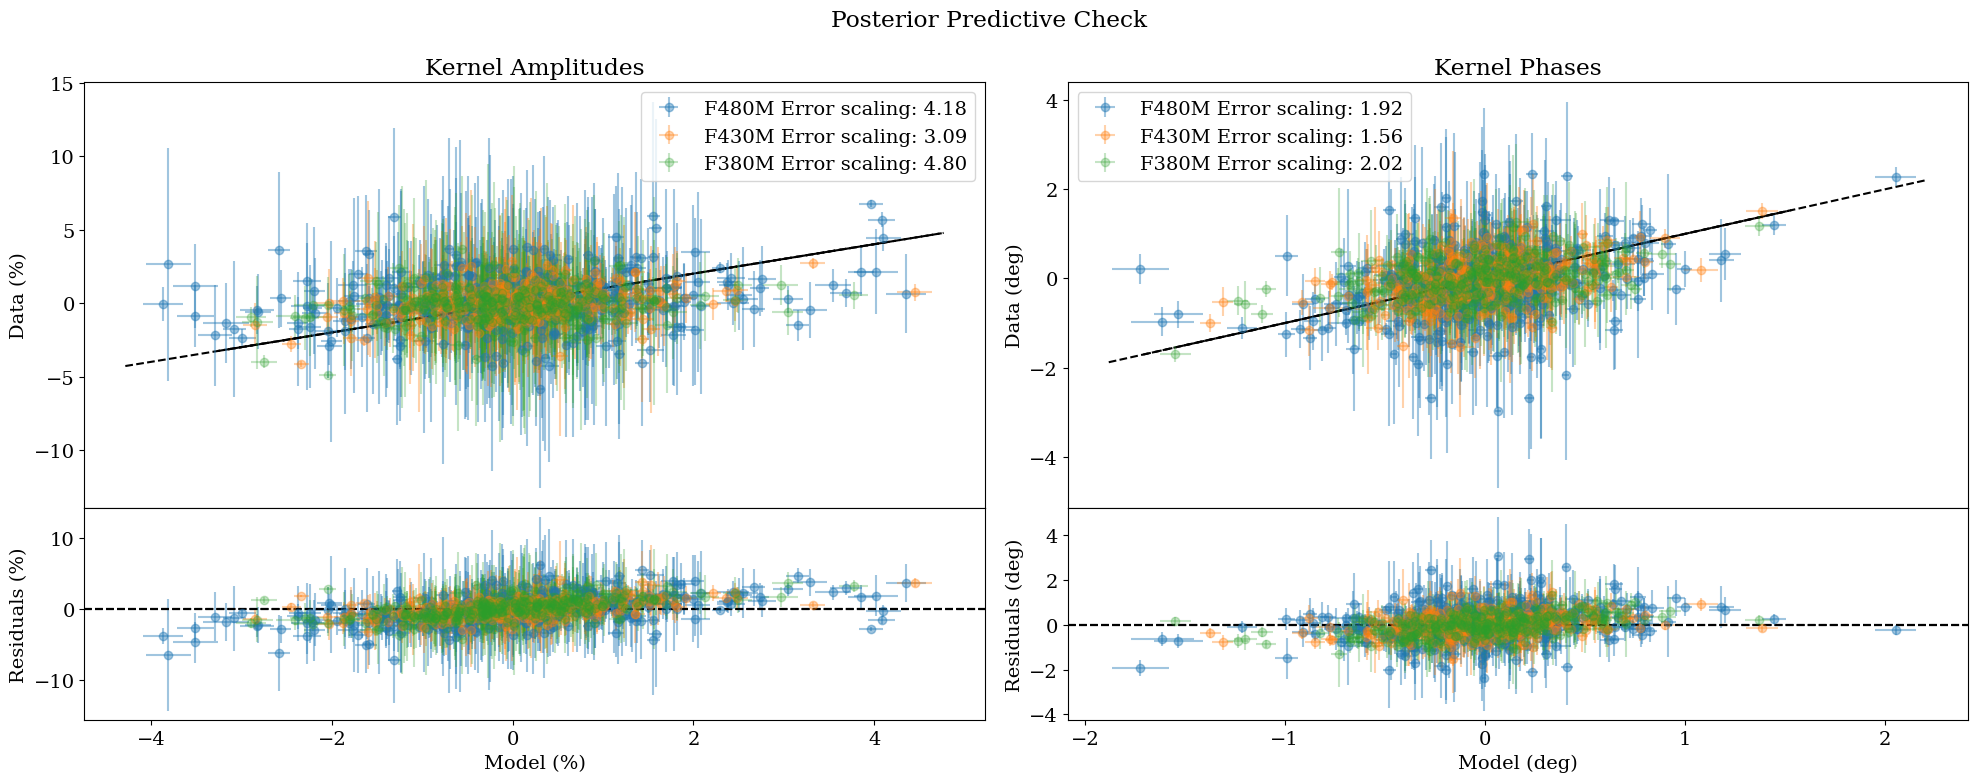

In [15]:
from matplotlib.gridspec import GridSpec
from amigo.stats import chi2, bin_data

# Create a 2x2 grid with shared x-axes in columns
fig = plt.figure(figsize=(20, 8))
fig.suptitle("Posterior Predictive Check")

gs = GridSpec(2, 2, height_ratios=[2, 1], hspace=0.0)  # less vertical spacing

# Main plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Residual plots
res1 = fig.add_subplot(gs[1, 0], sharex=ax1)
res2 = fig.add_subplot(gs[1, 1], sharex=ax2)

print("RMS residual / median data error")

alpha = 0.5
for i, filt in enumerate(["F480M", "F430M", "F380M"]):

    vis_pred = vis_analysis[filt]["vis_pred"]
    vis_std = vis_analysis[filt]["vis_std"]
    vis = vis_analysis[filt]["vis"]
    d_vis = vis_analysis[filt]["d_vis"]
    phi_pred = vis_analysis[filt]["phi_pred"]
    phi_std = vis_analysis[filt]["phi_std"]
    phi = vis_analysis[filt]["phi"]
    d_phi = vis_analysis[filt]["d_phi"]
    vis_jitter = vis_analysis[filt]["vis_jitter"]
    phi_jitter = vis_analysis[filt]["phi_jitter"]

    # Reduce Chi squared
    ddof = len(d_vis) - 3
    vis_chi2 = chi2(vis, vis_pred, d_vis, ddof)
    phi_chi2 = chi2(phi, phi_pred, d_phi, ddof)

    # RMS and Median Error
    rms = lambda x: np.sqrt(np.mean(x**2))
    med_err = lambda x: np.median(np.abs(x))
    vis_precision = rms(vis_pred - vis) / med_err(d_vis)
    phi_precision = rms(phi_pred - phi) / med_err(d_phi)
    print(f"{filt}:")
    print(f"  Vis: {vis_precision:.4f} - {rms(vis_pred - vis):.4f} - {med_err(d_vis):.4f}")
    print(f"  Phi: {phi_precision:.4f} - {rms(phi_pred - phi):.4f} - {med_err(d_phi):.4f}")

    # y = x plotting lines
    vis_med = np.nanmedian(vis_std)
    vis_min, vis_max = np.nanmin(vis_pred), np.nanmax(vis_pred)
    vis_121 = np.linspace(vis_min - 5 * vis_med, vis_max + 5 * vis_med, 100)

    phi_med = np.nanmedian(phi_std)
    phi_min, phi_max = np.nanmin(phi_pred), np.nanmax(phi_pred)
    phi_121 = np.linspace(phi_min - 5 * phi_med, phi_max + 5 * phi_med, 100)

    errplt = lambda ax, *args, **kwargs: ax.errorbar(
        *args, fmt="o", alpha=alpha, color=f"C{i}", **kwargs
    )
    print(alpha)
    alpha -= 0.075

    ax1.plot(vis_121, vis_121, "k--")
    errplt(ax1, vis_pred, vis, yerr=d_vis, xerr=vis_std)
    errplt(res1, vis_pred, vis_pred - vis, yerr=d_vis, xerr=vis_std)
    errplt(ax1, [], [], xerr=[], yerr=[], label=rf"{filt} Error scaling: {vis_jitter:.2f}")

    ax2.plot(phi_121, phi_121, "k--")
    errplt(ax2, phi_pred, phi, yerr=d_phi, xerr=phi_std)
    errplt(res2, phi_pred, phi_pred - phi, yerr=d_phi, xerr=phi_std)
    errplt(ax2, [], [], xerr=[], yerr=[], label=rf"{filt} Error scaling: {phi_jitter:.2f}")

    ax1.set(title="Kernel Amplitudes", ylabel="Data (%)", xlabel="Model (%)")
    ax2.set(title="Kernel Phases",  ylabel="Data (deg)", xlabel="Model (deg)")

    res1.set(ylabel="Residuals (%)", xlabel="Model (%)")
    res2.set(ylabel="Residuals (deg)", xlabel="Model (deg)")
    ax1.legend()
    ax2.legend()

    res1.axhline(0, color="k", ls="--")
    res2.axhline(0, color="k", ls="--")

plt.tight_layout()
plt.show()

RMS residual / median data error
F480M:
  Vis: 1.25 - 1.08 - 0.87
  Phi: 1.46 - 0.29 - 0.20
F430M:
  Vis: 1.20 - 0.65 - 0.55
  Phi: 1.14 - 0.18 - 0.16
F380M:
  Vis: 1.21 - 0.82 - 0.68
  Phi: 1.37 - 0.21 - 0.15


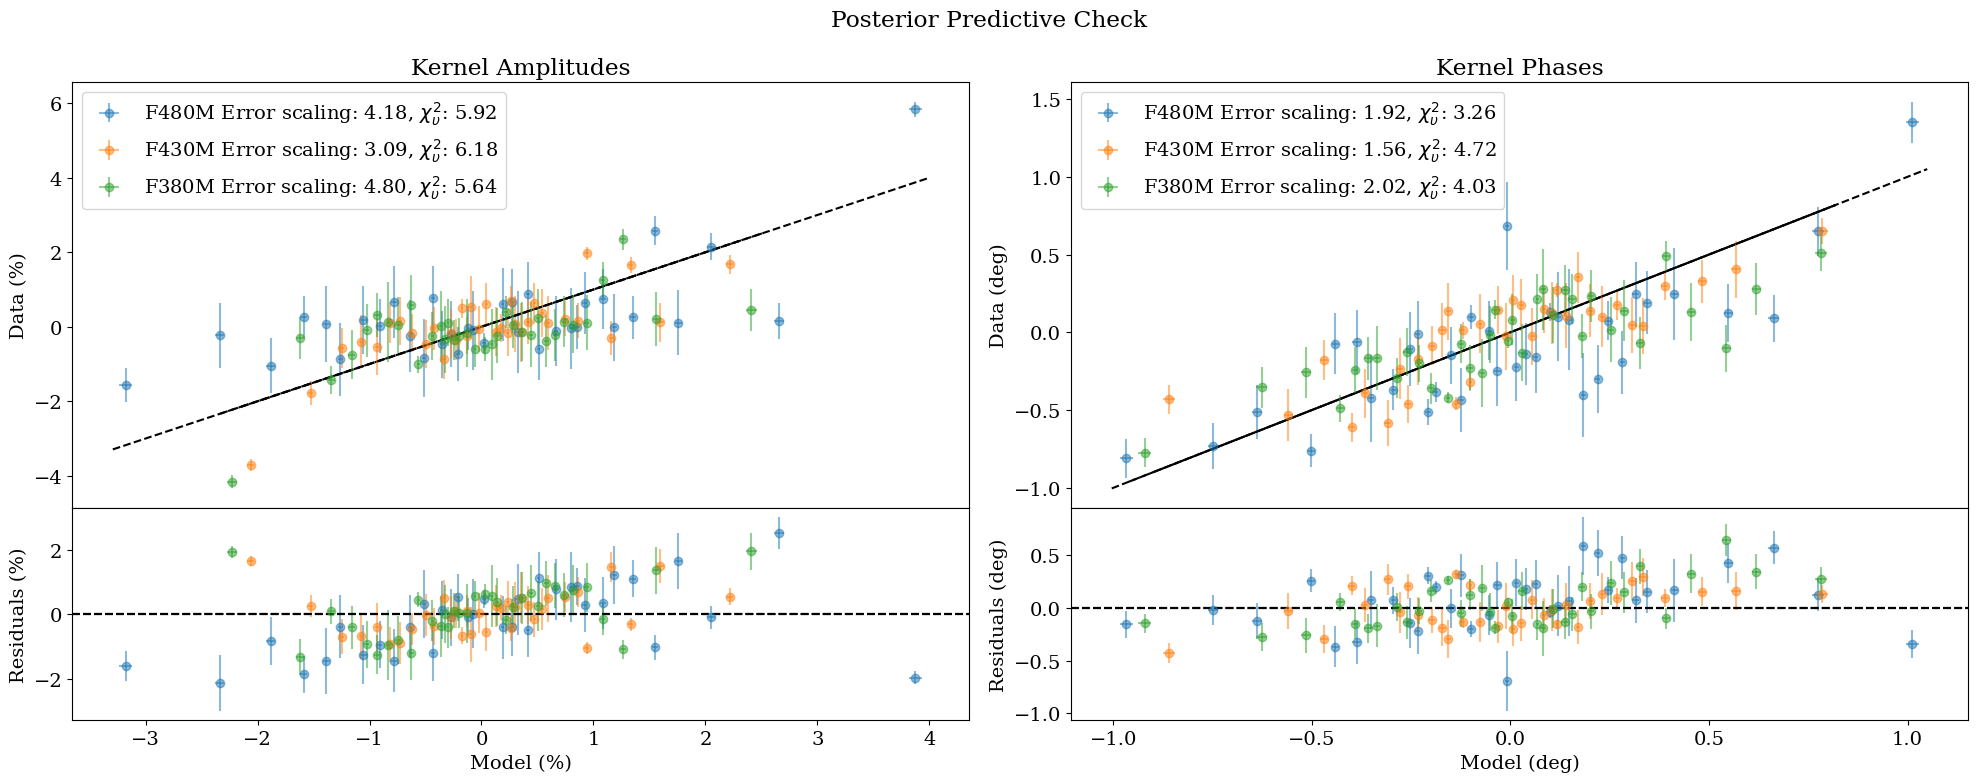

In [16]:
# Create a 2x2 grid with shared x-axes in columns
fig = plt.figure(figsize=(20, 8))
fig.suptitle("Posterior Predictive Check")

gs = GridSpec(2, 2, height_ratios=[2, 1], hspace=0.0)  # less vertical spacing

# Main plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Residual plots
res1 = fig.add_subplot(gs[1, 0], sharex=ax1)
res2 = fig.add_subplot(gs[1, 1], sharex=ax2)

print("RMS residual / median data error")
for i, filt in enumerate(["F480M", "F430M", "F380M"]):

    vis_pred = vis_analysis[filt]["vis_pred"]
    vis_std = vis_analysis[filt]["vis_std"]
    vis = vis_analysis[filt]["vis"]
    d_vis = vis_analysis[filt]["d_vis"]
    phi_pred = vis_analysis[filt]["phi_pred"]
    phi_std = vis_analysis[filt]["phi_std"]
    phi = vis_analysis[filt]["phi"]
    d_phi = vis_analysis[filt]["d_phi"]
    vis_jitter = vis_analysis[filt]["vis_jitter"]
    phi_jitter = vis_analysis[filt]["phi_jitter"]


    # Bin the visibilities
    bin_inds = np.array_split(np.argsort(vis_pred), n_bins)
    vis_pred, vis_std = bin_data(vis_pred, vis_std, bin_inds)
    vis, d_vis = bin_data(vis, d_vis, bin_inds)

    # Bin the phases
    bin_inds = np.array_split(np.argsort(phi_pred), n_bins)
    phi_pred, phi_std = bin_data(phi_pred, phi_std, bin_inds)
    phi, d_phi = bin_data(phi, d_phi, bin_inds)

    # Reduce Chi squared
    ddof = len(d_vis) - 3
    vis_chi2 = chi2(vis, vis_pred, d_vis, ddof)
    phi_chi2 = chi2(phi, phi_pred, d_phi, ddof)

    # RMS and Median Error
    rms = lambda x: np.sqrt(np.mean(x**2))
    med_err = lambda x: np.median(np.abs(x))
    vis_precision = rms(vis_pred - vis) / med_err(d_vis)
    phi_precision = rms(phi_pred - phi) / med_err(d_phi)
    print(f"{filt}:")
    print(f"  Vis: {vis_precision:.2f} - {rms(vis_pred - vis):.2f} - {med_err(d_vis):.2f}")
    print(f"  Phi: {phi_precision:.2f} - {rms(phi_pred - phi):.2f} - {med_err(d_phi):.2f}")

    # y = x plotting lines
    vis_med = np.nanmedian(vis_std)
    vis_min, vis_max = np.nanmin(vis_pred), np.nanmax(vis_pred)
    vis_121 = np.linspace(vis_min - 5 * vis_med, vis_max + 5 * vis_med, 100)

    phi_med = np.nanmedian(phi_std)
    phi_min, phi_max = np.nanmin(phi_pred), np.nanmax(phi_pred)
    phi_121 = np.linspace(phi_min - 5 * phi_med, phi_max + 5 * phi_med, 100)

    errplt = lambda ax, *args, **kwargs: ax.errorbar(
        *args, fmt="o", alpha=0.5, color=f"C{i}", **kwargs
    )

    ax1.plot(vis_121, vis_121, "k--")
    errplt(ax1, vis_pred, vis, yerr=d_vis, xerr=vis_std)
    errplt(res1, vis_pred, vis_pred - vis, yerr=d_vis, xerr=vis_std)
    errplt(ax1, [], [], xerr=[], yerr=[], label=rf"{filt} Error scaling: {vis_jitter:.2f}, $\chi^2_\upsilon$: {vis_chi2:.2f}")

    ax2.plot(phi_121, phi_121, "k--")
    errplt(ax2, phi_pred, phi, yerr=d_phi, xerr=phi_std)
    errplt(res2, phi_pred, phi_pred - phi, yerr=d_phi, xerr=phi_std)
    errplt(ax2, [], [], xerr=[], yerr=[], label=rf"{filt} Error scaling: {phi_jitter:.2f}, $\chi^2_\upsilon$: {phi_chi2:.2f}")

    ax1.set(title="Kernel Amplitudes", ylabel="Data (%)", xlabel="Model (%)")
    ax2.set(title="Kernel Phases",  ylabel="Data (deg)", xlabel="Model (deg)")

    res1.set(ylabel="Residuals (%)", xlabel="Model (%)")
    res2.set(ylabel="Residuals (deg)", xlabel="Model (deg)")
    ax1.legend()
    ax2.legend()

    res1.axhline(0, color="k", ls="--")
    res2.axhline(0, color="k", ls="--")

plt.tight_layout()
plt.show()

# Examine the fit to the first companion

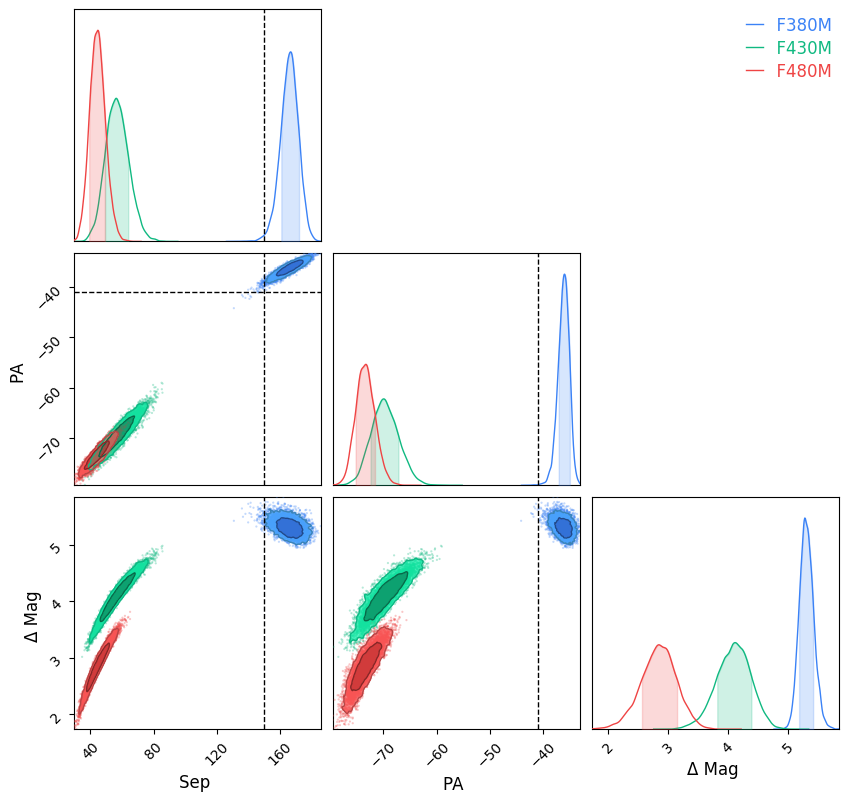

In [17]:
from chainconsumer import ChainConsumer, Chain, Truth
import pandas as pd

n_sigma = 3
true_ra, true_dec = binaries[0]

c = ChainConsumer()
truths = {
    "Δ Dec": true_dec,
    "Δ RA": true_ra,
    "Sep": np.hypot(true_ra, true_dec),
    "PA": dlu.rad2deg(np.arctan2(true_dec, true_ra)),
}


c.add_truth(Truth(location=truths))

# Plot the joint fit data or the individual fits
joint = False

# Plot polar or cartesian coordinates
polar = True

for filt in vis_analysis.keys():
    if polar:
        params = ["Sep b", "PA b",  f"Δ Mag b {filt}"]
        keys = ["Sep", "PA", "Δ Mag"]
    else:
        params = ["Δ RA b", "Δ Dec b", f"Δ Mag b {filt}"]
        keys = ["Δ RA", "Δ Dec", "Δ Mag"]

    if joint:
        results = joint_sampler.get_samples()
    else:
        sampler = samplers[filt]
        results = sampler.get_samples()
    results = {key: results[param] for key, param in zip(keys, params)}
    cc_df = pd.DataFrame.from_dict(results)

    c.add_chain(
        Chain(
            samples=cc_df,
            name=filt,
            plot_cloud=True,
            marker_style="*",
            marker_size=100,
        )
    )

c.plotter.plot()
plt.show()

# Examine the fit to the second companion

Note its signal is much harder to detect, so we plot the _joint_ fit

/home/louis/miniconda3/envs/jax_gpu/lib/python3.13/site-packages/chainconsumer/plotter.py:864: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(base.extents[p1])
/home/louis/miniconda3/envs/jax_gpu/lib/python3.13/site-packages/chainconsumer/plotter.py:865: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(base.extents[p2])
/home/louis/miniconda3/envs/jax_gpu/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


IndexError: index 0 is out of bounds for axis 0 with size 0

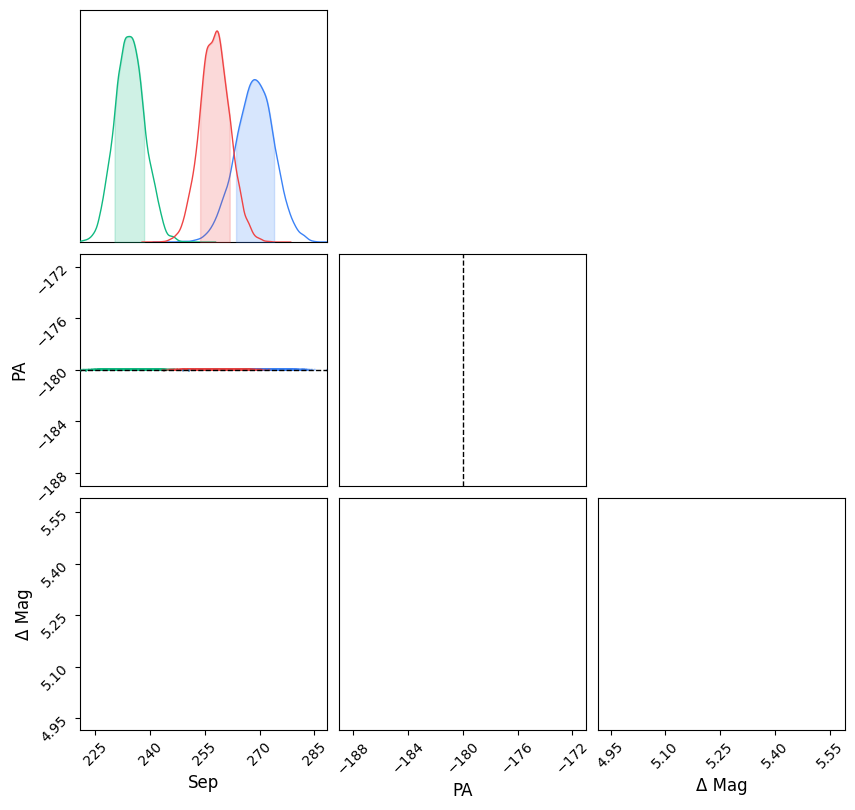

: 

In [ ]:
from chainconsumer import ChainConsumer, Chain, Truth
import pandas as pd


true_ra, true_dec = binaries[1]
truths = {
    "Δ Dec": true_dec,
    "Δ RA": true_ra,
    "Sep": np.hypot(true_ra, true_dec),
    "PA": dlu.rad2deg(np.arctan2(true_dec, true_ra)),
}

c = ChainConsumer()
c.add_truth(Truth(location=truths))

# Plot the joint fit data or the individual fits
joint = False

# Plot polar or cartesian coordinates
polar = True

for filt in vis_analysis.keys():
    if polar:
        params = ["Sep c", "PA c", f"Δ Mag c {filt}"]
        keys = ["Sep", "PA", "Δ Mag"]
    else:
        params = ["Δ RA c", "Δ Dec c", f"Δ Mag c {filt}"]
        keys = ["Δ RA", "Δ Dec", "Δ Mag"]

    if joint:
        results = joint_sampler.get_samples()
    else:
        sampler = samplers[filt]
        results = sampler.get_samples()
    results = {key: results[param] for key, param in zip(keys, params)}
    cc_df = pd.DataFrame.from_dict(results)

    c.add_chain(
        Chain(
            samples=cc_df,
            name=f"{filt}",
            plot_cloud=True,
            marker_style="*",
            marker_size=100,
        )
    )

c.plotter.plot()
plt.show()

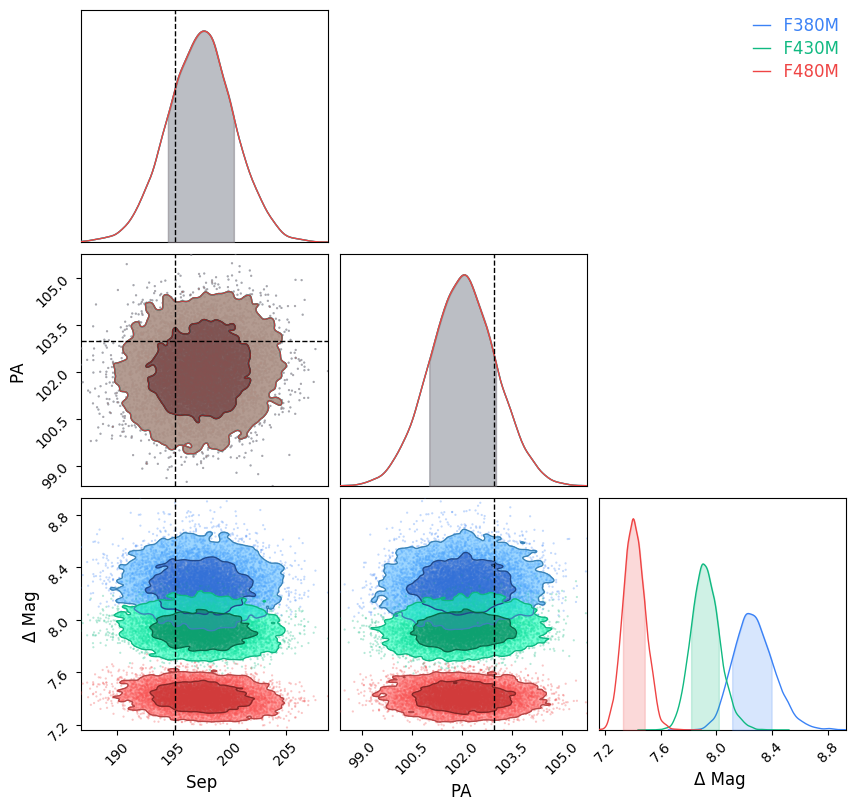

: 

In [ ]:
from chainconsumer import ChainConsumer, Chain, Truth
import pandas as pd

n_sigma = 3
true_ra, true_dec = binaries[0]

c = ChainConsumer()
truths = {
    "Δ Dec": true_dec,
    "Δ RA": true_ra,
    "Sep": np.hypot(true_ra, true_dec),
    "PA": dlu.rad2deg(np.arctan2(true_dec, true_ra)),
}


c.add_truth(Truth(location=truths))

# Plot the joint fit data or the individual fits
joint = True

# Plot polar or cartesian coordinates
polar = True

for filt in vis_analysis.keys():
    if polar:
        params = ["Sep b", "PA b", f"Δ Mag b {filt}"]
        keys = ["Sep", "PA", "Δ Mag"]
    else:
        params = ["Δ RA b", "Δ Dec b", f"Δ Mag b {filt}"]
        keys = ["Δ RA", "Δ Dec", "Δ Mag"]

    if joint:
        results = joint_sampler.get_samples()
    else:
        sampler = samplers[filt]
        results = sampler.get_samples()
    results = {key: results[param] for key, param in zip(keys, params)}
    cc_df = pd.DataFrame.from_dict(results)

    c.add_chain(
        Chain(
            samples=cc_df,
            name=filt,
            plot_cloud=True,
            marker_style="*",
            marker_size=100,
        )
    )

c.plotter.plot()
plt.show()

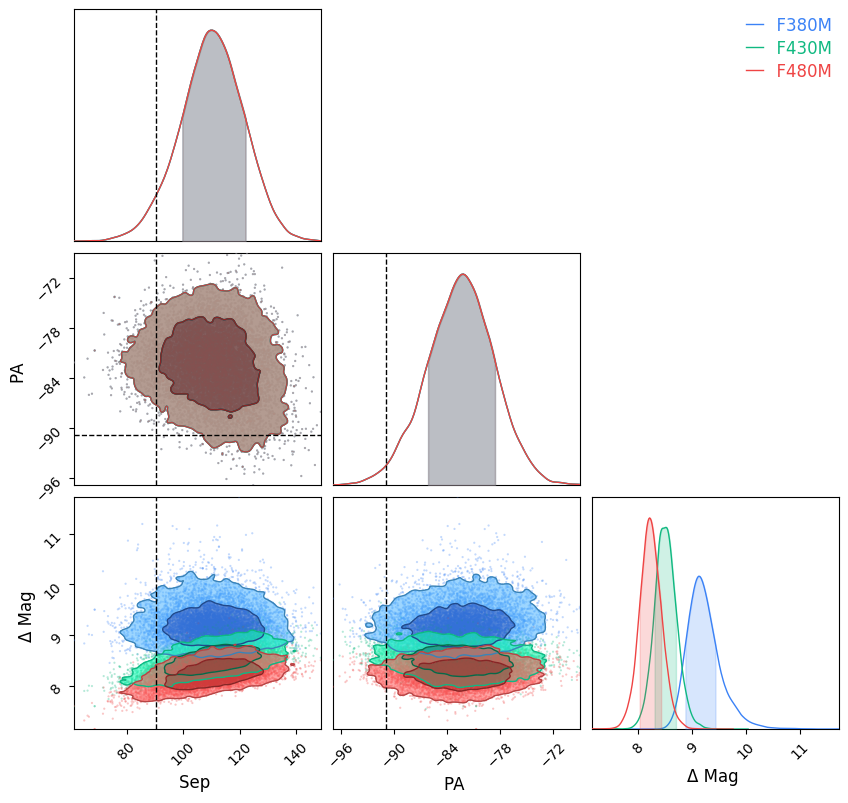

In [ ]:
from chainconsumer import ChainConsumer, Chain, Truth
import pandas as pd


true_ra, true_dec = binaries[1]
truths = {
    "Δ Dec": true_dec,
    "Δ RA": true_ra,
    "Sep": np.hypot(true_ra, true_dec),
    "PA": dlu.rad2deg(np.arctan2(true_dec, true_ra)),
}

c = ChainConsumer()
c.add_truth(Truth(location=truths))

# Plot the joint fit data or the individual fits
joint = True

# Plot polar or cartesian coordinates
polar = True

for filt in vis_analysis.keys():
    if polar:
        params = ["Sep c", "PA c", f"Δ Mag c {filt}"]
        keys = ["Sep", "PA", "Δ Mag"]
    else:
        params = ["Δ RA c", "Δ Dec c", f"Δ Mag c {filt}"]
        keys = ["Δ RA", "Δ Dec", "Δ Mag"]

    if joint:
        results = joint_sampler.get_samples()
    else:
        sampler = samplers[filt]
        results = sampler.get_samples()
    results = {key: results[param] for key, param in zip(keys, params)}
    cc_df = pd.DataFrame.from_dict(results)

    c.add_chain(
        Chain(
            samples=cc_df,
            name=f"{filt}",
            plot_cloud=True,
            marker_style="*",
            marker_size=100,
        )
    )

c.plotter.plot()
plt.show()

# Re-run the analysis with the known binaries subtracted

In [ ]:
import dLux.utils as dlu
from amigo.misc import tqdm

# Calculate the log-likelihoods
cln_outputs = {}
for filt, oi_obj in tqdm(oi_data_objs_clean.items()):

    cln_outputs[filt] = analyse_vis(
        oi_obj,
        size=500,  # mas
        n_pts=500,  # number of points in the final grid
        n_grid=60,  # number of initial grid points
        n_batch=1,  # number of batches to calculate the likelihood
        min_flux=-6,  # minimum log flux range
        tol=1e-8,  # tolerance for the optimizer (linear OR log space)
        max_steps=512,  # maximum number of steps for the optimizer
        n_sigma=3.0,  # number of sigma for the upper limits
        log=False,
    )

  0%|          | 0/3 [00:00<?, ?it/s]

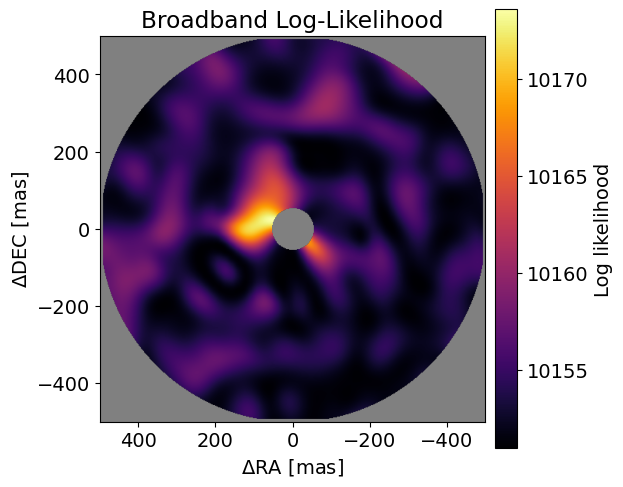

In [ ]:
bb_loglike = np.array([vals["loglike_im"] for vals in cln_outputs.values()]).sum(0)
extent = cln_outputs["F480M"]["extent"]

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
im = ax.imshow(bb_loglike, cmap=inferno, aspect="equal", extent=extent)
fig.colorbar(im, ax=ax, shrink=0.95, label="Log likelihood", pad=0.02)
ax.set(
    title="Broadband Log-Likelihood",
    xlabel="$\\Delta$RA [mas]",
    ylabel="$\\Delta$DEC [mas]",
);

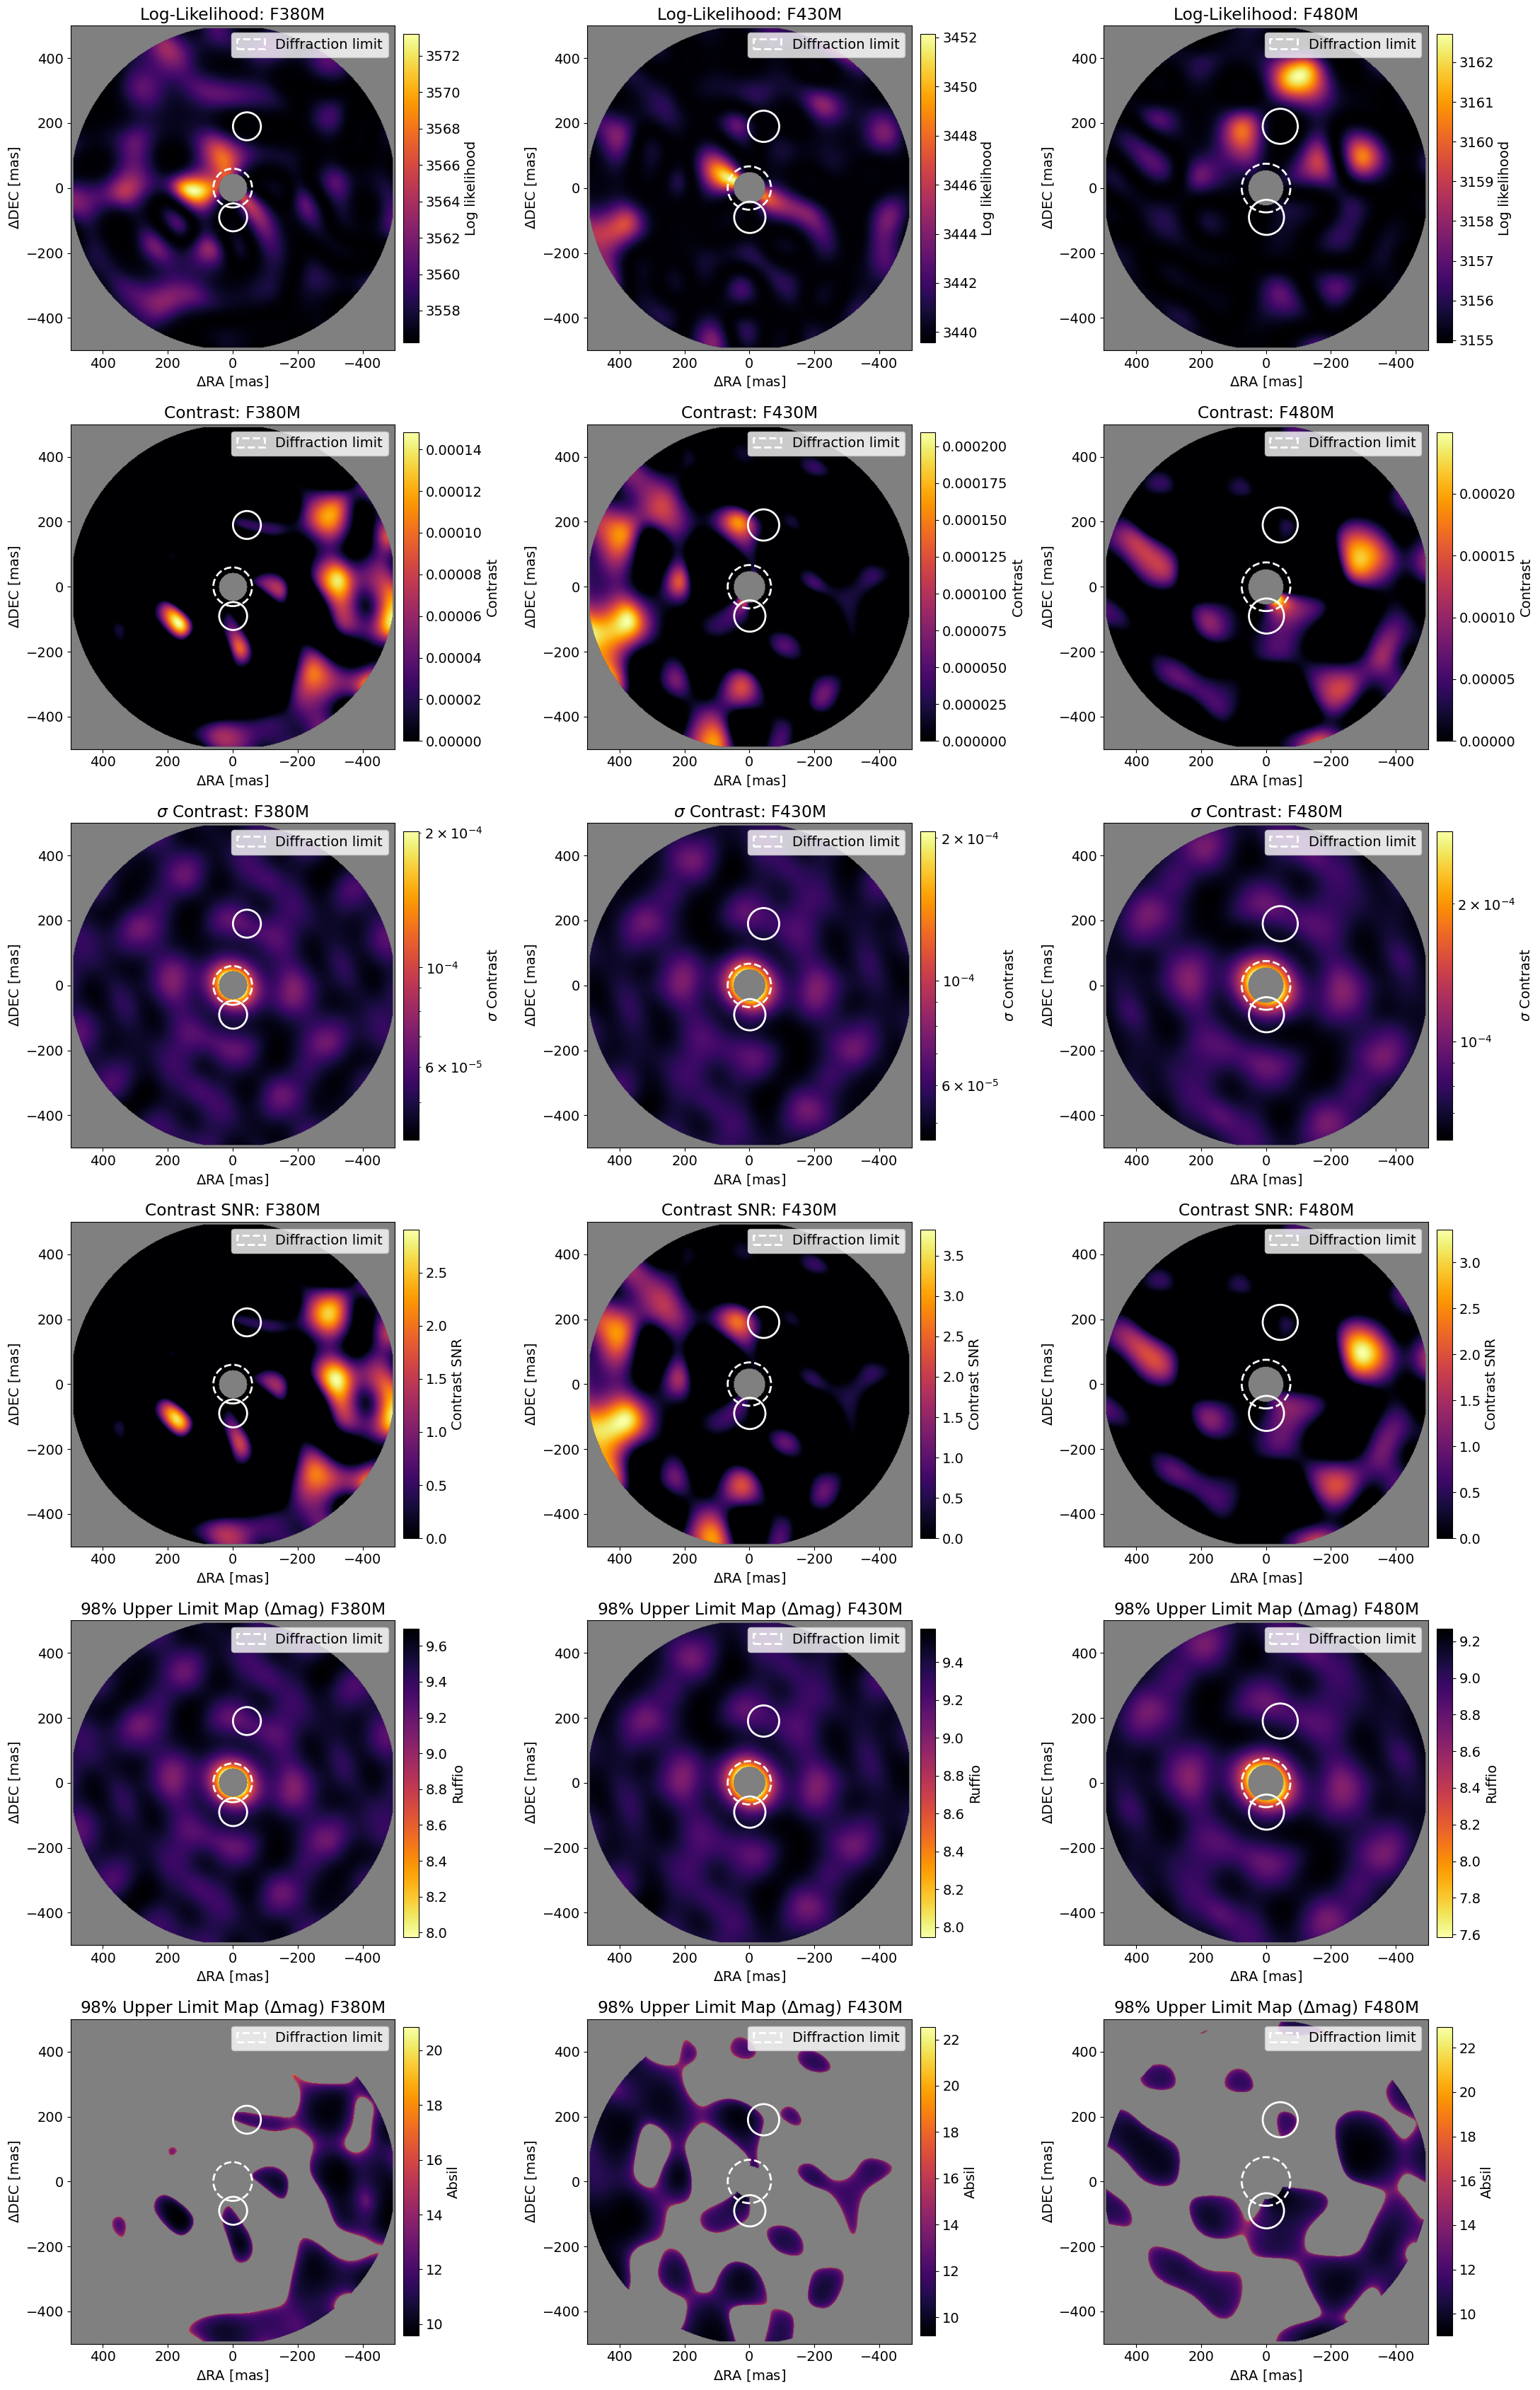

In [ ]:
plt.figure(figsize=(22, 34))
for i, (filt, output) in enumerate(cln_outputs.items()):
    loglike_im = output["loglike_im"]
    contrast_im = output["contrast_im"]
    sigma_im = output["sigma_im"]
    ruffio_im = output["ruffio_im"]
    limits_im = output["limits_im"]
    min_fov, max_fov = output["fov"]
    extent = output["extent"]
    wavel = output["oi_obj"].wavel

    diff_lim = 1e3 * dlu.rad2arcsec(wavel / optics.diameter)

    def add_to_ax(ax):
        [ax.add_patch(make_circle(binary, 2 * min_fov)) for binary in binaries]
        ax.add_patch(make_circle((0, 0), diff_lim, ls="--", label="Diffraction limit"))
        ax.legend()

    #
    ax = plt.subplot(6, 3, i + 1)
    plt.imshow(loglike_im, cmap=inferno, aspect="equal", extent=extent)
    plt.colorbar(shrink=0.95, label="Log likelihood", pad=0.02)
    ax.set(
        title=f"Log-Likelihood: {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax)

    norm = mpl.colors.PowerNorm(1, vmin=0)
    ax = plt.subplot(6, 3, i + 4)
    plt.imshow(contrast_im, cmap=inferno, aspect="equal", extent=extent, norm=norm)
    plt.colorbar(shrink=0.95, label="Contrast", pad=0.02)
    ax.set(
        title=f"Contrast: {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax)

    norm = mpl.colors.LogNorm()
    ax = plt.subplot(6, 3, i + 7)
    plt.imshow(sigma_im, cmap=inferno, aspect="equal", extent=extent, norm=norm)
    plt.colorbar(shrink=0.95, label=r"$\sigma$ Contrast", pad=0.02)
    ax.set(
        title=rf"$\sigma$ Contrast: {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax)

    norm = mpl.colors.PowerNorm(1, vmin=0)
    ax = plt.subplot(6, 3, i + 10)
    plt.imshow(contrast_im / sigma_im, cmap=inferno, aspect="equal", extent=extent, norm=norm)
    plt.colorbar(shrink=0.95, label="Contrast SNR", pad=0.02)
    ax.set(
        title=f"Contrast SNR: {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax)

    ax = plt.subplot(6, 3, i + 13)
    plt.imshow(
        -2.5 * np.log10(ruffio_im), cmap=inferno_r, aspect="equal", extent=extent
    )
    # plt.imshow(ruffio_im, cmap=inferno_r, aspect="equal", extent=extent)
    plt.colorbar(shrink=0.95, label="Ruffio", pad=0.02)
    ax.set(
        title=f"98% Upper Limit Map ($\\Delta$mag) {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax)

    ax = plt.subplot(6, 3, i + 16)
    plt.imshow(-2.5 * np.log10(limits_im), cmap=inferno, aspect="equal", extent=extent)
    plt.colorbar(shrink=0.95, label="Absil", pad=0.02)
    ax.set(
        title=f"98% Upper Limit Map ($\\Delta$mag) {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax)

plt.tight_layout()
plt.show()

# Look at the upper limits of the data with the best-fit binaries subtracted

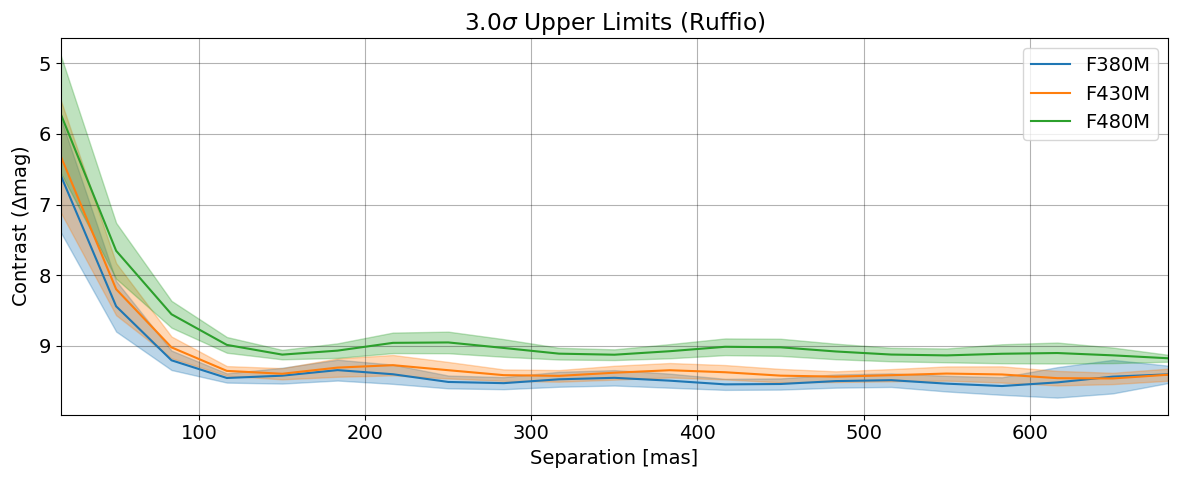

In [ ]:
plt.figure(figsize=(12, 5))
for i, (filt, output) in enumerate(cln_outputs.items()):
    rad_width, avg_width, std_width = output["ruffio"]
    n_sigma = output["n_sigma"]

    dx = 1000 / 60
    # plt.title("98% Upper Limits (Ruffio)")
    plt.title(rf"{n_sigma}$\sigma$ Upper Limits (Ruffio)")
    plt.plot(rad_width * dx, avg_width, label=f"{filt}")
    plt.fill_between(
        rad_width * dx,
        avg_width - std_width,
        avg_width + std_width,
        color=f"C{i}",
        alpha=0.3,
    )
    plt.ylabel("Contrast ($\\Delta$mag)")
    plt.xlabel("Separation [mas]")
    plt.gca().invert_yaxis()
    plt.xlim(
        np.nanmin(rad_width * dx + avg_width * 0.0),
        np.nanmax(rad_width * dx + avg_width * 0.0),
    )
    plt.grid(color="black", alpha=0.3)
    plt.legend(loc="best")
plt.tight_layout()
plt.show()